# Promotion Analysis and Statistical Validation

## Objective

Determine how promotion behavior differs between the final consumer segments and identify evidence that may support later promotion-efficiency, growth or reactivation decisions.

### Required analytical inputs

- `analytics.customer_metrics`
- `analytics.promotion_metrics`
- `analytics.customer_category_metrics`
- `analytics.customer_segments`

### Mandatory comparison areas

- promotion purchase share;
- promotion spend share;
- promotional spend;
- non-promotional spend;
- promotional basket value;
- non-promotional basket value;
- purchase activity;
- category-level promotional behavior.

### Interpretation boundaries

Observed promotion activity is descriptive.

This notebook does **not** claim:

- profitability;
- margin improvement;
- incremental revenue;
- causal promotion lift.

A customer may frequently purchase promotional baskets without having most sales value generated by promotional lines.

`promo_sales` and `nonpromo_sales` classify **entire basket sales** according to whether the basket contains at least one promotional line.

`promotion_spend_share`, by contrast, represents sales on promotional **lines** divided by total customer sales.

These concepts must remain distinct throughout the analysis.


## 1. Environment and database connection

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ENV_PATH = PROJECT_ROOT / ".env"

if not ENV_PATH.exists():
    raise FileNotFoundError(
        f"Missing environment file: {ENV_PATH}"
    )

def load_env_file(path: Path) -> None:
    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()

        if (
            not line
            or line.startswith("#")
            or "=" not in line
        ):
            continue

        key, value = line.split("=", 1)

        key = key.strip()
        value = value.strip()

        if (
            len(value) >= 2
            and value[0] == value[-1]
            and value[0] in {"'", '"'}
        ):
            value = value[1:-1]

        os.environ.setdefault(key, value)

load_env_file(ENV_PATH)

required_env = [
    "DB_HOST",
    "DB_PORT",
    "DB_NAME",
    "DB_USER",
    "DB_PASSWORD",
]

missing_env = [
    key
    for key in required_env
    if not os.getenv(key)
]

if missing_env:
    raise RuntimeError(
        "Missing required environment variables: "
        f"{missing_env}"
    )

database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.environ["DB_USER"],
    password=os.environ["DB_PASSWORD"],
    host=os.environ["DB_HOST"],
    port=int(os.environ["DB_PORT"]),
    database=os.environ["DB_NAME"],
)

engine = create_engine(database_url)

with engine.connect() as connection:
    database_check = connection.execute(
        text(
            '''
            SELECT
                current_database() AS database_name,
                current_user AS database_user
            '''
        )
    ).mappings().one()

print(
    "Database connection: OK | "
    f"database={database_check['database_name']} | "
    f"user={database_check['database_user']}"
)


Database connection: OK | database=fmcg_consumer_growth | user=fmcg_analytics


## 2. Load analytical inputs

The analysis starts by validating the persisted segmentation output against the customer, promotion and category analytical layers.

No metric is recalculated from raw transactions in this notebook unless a validation specifically requires it.


In [2]:
customer_metrics = pd.read_sql_query(
    text(
        '''
        SELECT
            customer_id,
            total_spend,
            total_transactions,
            average_basket_value,
            active_months,
            purchase_frequency,
            recency_days,
            average_items_per_basket,
            category_diversity,
            promotion_purchase_share,
            promotion_spend_share,
            top_category,
            top_category_share
        FROM analytics.customer_metrics
        ORDER BY customer_id
        '''
    ),
    engine,
)

promotion_metrics = pd.read_sql_query(
    text(
        '''
        SELECT
            customer_id,
            promo_baskets,
            nonpromo_baskets,
            promo_sales,
            nonpromo_sales,
            promo_average_basket_value,
            nonpromo_average_basket_value,
            promotion_purchase_share
                AS pm_promotion_purchase_share,
            promotion_spend_share
                AS pm_promotion_spend_share
        FROM analytics.promotion_metrics
        ORDER BY customer_id
        '''
    ),
    engine,
)

customer_category_metrics = pd.read_sql_query(
    text(
        '''
        SELECT
            customer_id,
            category,
            category_spend,
            category_transactions,
            category_quantity,
            category_spend_share,
            category_promo_spend,
            category_promo_transactions,
            category_promo_spend_share,
            category_rank
        FROM analytics.customer_category_metrics
        ORDER BY customer_id, category_rank
        '''
    ),
    engine,
)

customer_segments = pd.read_sql_query(
    text(
        '''
        SELECT
            customer_id,
            segment_id,
            segment_name,
            model_version
        FROM analytics.customer_segments
        ORDER BY customer_id
        '''
    ),
    engine,
)

print(
    f"customer_metrics rows: "
    f"{len(customer_metrics):,}"
)

print(
    f"promotion_metrics rows: "
    f"{len(promotion_metrics):,}"
)

print(
    f"customer_category_metrics rows: "
    f"{len(customer_category_metrics):,}"
)

print(
    f"customer_segments rows: "
    f"{len(customer_segments):,}"
)


customer_metrics rows: 2,500
promotion_metrics rows: 2,500
customer_category_metrics rows: 286,548
customer_segments rows: 2,500


In [3]:
# Normalize database numeric values for analytical comparison.

customer_numeric_columns = [
    "total_spend",
    "total_transactions",
    "average_basket_value",
    "active_months",
    "purchase_frequency",
    "recency_days",
    "average_items_per_basket",
    "category_diversity",
    "promotion_purchase_share",
    "promotion_spend_share",
    "top_category_share",
]

promotion_numeric_columns = [
    "promo_baskets",
    "nonpromo_baskets",
    "promo_sales",
    "nonpromo_sales",
    "promo_average_basket_value",
    "nonpromo_average_basket_value",
    "pm_promotion_purchase_share",
    "pm_promotion_spend_share",
]

category_numeric_columns = [
    "category_spend",
    "category_transactions",
    "category_quantity",
    "category_spend_share",
    "category_promo_spend",
    "category_promo_transactions",
    "category_promo_spend_share",
    "category_rank",
]

for column in customer_numeric_columns:
    customer_metrics[column] = pd.to_numeric(
        customer_metrics[column],
        errors="coerce",
    )

for column in promotion_numeric_columns:
    promotion_metrics[column] = pd.to_numeric(
        promotion_metrics[column],
        errors="coerce",
    )

for column in category_numeric_columns:
    customer_category_metrics[column] = pd.to_numeric(
        customer_category_metrics[column],
        errors="coerce",
    )


## 3. Grain and Customer-Coverage Validation

Expected grain:

- `customer_metrics`: one row per customer;
- `promotion_metrics`: one row per customer;
- `customer_segments`: one row per customer;
- `customer_category_metrics`: one row per customer × category.

The three customer-level tables must cover exactly the same 2,500 customers.


In [4]:
assert len(customer_metrics) == 2500
assert len(promotion_metrics) == 2500
assert len(customer_segments) == 2500

assert (
    customer_metrics["customer_id"]
    .nunique()
    == 2500
)

assert (
    promotion_metrics["customer_id"]
    .nunique()
    == 2500
)

assert (
    customer_segments["customer_id"]
    .nunique()
    == 2500
)

assert (
    customer_category_metrics[
        ["customer_id", "category"]
    ]
    .duplicated()
    .sum()
    == 0
)

customer_ids = set(
    customer_metrics["customer_id"]
)

promotion_ids = set(
    promotion_metrics["customer_id"]
)

segment_ids = set(
    customer_segments["customer_id"]
)

category_customer_ids = set(
    customer_category_metrics["customer_id"]
)

assert customer_ids == promotion_ids
assert customer_ids == segment_ids
assert customer_ids == category_customer_ids

assert (
    customer_segments["segment_id"]
    .nunique()
    == 3
)

assert (
    customer_segments["segment_name"]
    .isna()
    .sum()
    == 0
)

segment_counts = (
    customer_segments
    .groupby(
        [
            "segment_id",
            "segment_name",
        ],
        as_index=False,
    )
    .agg(
        customers=(
            "customer_id",
            "size",
        )
    )
    .sort_values("segment_id")
)

print("PROMOTION INPUT COVERAGE")

print(
    f"Customer-level customers: "
    f"{len(customer_ids):,}"
)

print(
    f"Category-level customers: "
    f"{len(category_customer_ids):,}"
)

print(
    f"Final segments: "
    f"{customer_segments['segment_id'].nunique()}"
)

print()
print(segment_counts.to_string(index=False))


PROMOTION INPUT COVERAGE
Customer-level customers: 2,500
Category-level customers: 2,500
Final segments: 3

 segment_id                      segment_name  customers
          1      High-Value Frequent Shoppers       1007
          2  Large-Basket Occasional Shoppers        902
          3 Low-Value Low-Engagement Shoppers        591


## 4. Customer-Level Promotion Reconciliation

The SQL layer contains two promotion concepts that must not be confused:

### Promotional basket classification

A basket is promotional when at least one valid line is promotional.

Therefore:

- `promo_sales` = total sales of entire promotional baskets;
- `nonpromo_sales` = total sales of entire non-promotional baskets.

These two values must reconstruct total customer sales.

### Promotional line share

`promotion_spend_share` measures promotional-line sales divided by total customer sales.

It is therefore not expected to equal `promo_sales / total_spend`.


In [5]:
promotion_customer = (
    customer_metrics
    .merge(
        promotion_metrics,
        on="customer_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        customer_segments,
        on="customer_id",
        how="inner",
        validate="one_to_one",
    )
)

assert len(promotion_customer) == 2500

basket_count_match = (
    promotion_customer[
        "total_transactions"
    ]
    == (
        promotion_customer["promo_baskets"]
        + promotion_customer["nonpromo_baskets"]
    )
)

sales_match = np.isclose(
    promotion_customer["total_spend"],
    (
        promotion_customer["promo_sales"]
        + promotion_customer["nonpromo_sales"]
    ),
    atol=0.01,
)

purchase_share_match = np.isclose(
    promotion_customer[
        "promotion_purchase_share"
    ],
    promotion_customer[
        "pm_promotion_purchase_share"
    ],
    atol=1e-10,
)

spend_share_match = np.isclose(
    promotion_customer[
        "promotion_spend_share"
    ],
    promotion_customer[
        "pm_promotion_spend_share"
    ],
    atol=1e-10,
)

assert basket_count_match.all()
assert sales_match.all()
assert purchase_share_match.all()
assert spend_share_match.all()

# Missing promotional/non-promotional basket value is valid only
# when that customer has no baskets of the corresponding type.

promo_abv_null = (
    promotion_customer[
        "promo_average_basket_value"
    ].isna()
)

nonpromo_abv_null = (
    promotion_customer[
        "nonpromo_average_basket_value"
    ].isna()
)

assert (
    promo_abv_null
    == (
        promotion_customer[
            "promo_baskets"
        ] == 0
    )
).all()

assert (
    nonpromo_abv_null
    == (
        promotion_customer[
            "nonpromo_baskets"
        ] == 0
    )
).all()


## 5. Revenue and Category Reconciliation

Overall sales must reconcile across:

- `customer_metrics`;
- promotional + non-promotional basket sales;
- `customer_category_metrics`;
- segment-attributed customer sales.

Category promotional spend is also reconciled against customer-level promotional-line spend.


In [6]:
customer_sales_total = (
    promotion_customer[
        "total_spend"
    ].sum()
)

basket_classified_sales_total = (
    promotion_customer[
        "promo_sales"
    ].sum()
    + promotion_customer[
        "nonpromo_sales"
    ].sum()
)

category_sales_total = (
    customer_category_metrics[
        "category_spend"
    ].sum()
)

segment_sales_total = (
    promotion_customer
    .groupby("segment_id")[
        "total_spend"
    ]
    .sum()
    .sum()
)

category_promo_line_sales = (
    customer_category_metrics[
        "category_promo_spend"
    ].sum()
)

customer_promo_line_sales = (
    (
        promotion_customer[
            "total_spend"
        ]
        * promotion_customer[
            "promotion_spend_share"
        ]
    )
    .sum()
)

assert np.isclose(
    customer_sales_total,
    8_057_443.80,
    atol=0.01,
)

assert np.isclose(
    customer_sales_total,
    basket_classified_sales_total,
    atol=0.01,
)

assert np.isclose(
    customer_sales_total,
    category_sales_total,
    atol=0.01,
)

assert np.isclose(
    customer_sales_total,
    segment_sales_total,
    atol=0.01,
)

assert np.isclose(
    category_promo_line_sales,
    customer_promo_line_sales,
    atol=0.01,
)

segment_reconciliation = (
    promotion_customer
    .groupby(
        [
            "segment_id",
            "segment_name",
        ],
        as_index=False,
    )
    .agg(
        customers=(
            "customer_id",
            "size",
        ),
        total_sales=(
            "total_spend",
            "sum",
        ),
        total_transactions=(
            "total_transactions",
            "sum",
        ),
        promo_baskets=(
            "promo_baskets",
            "sum",
        ),
        nonpromo_baskets=(
            "nonpromo_baskets",
            "sum",
        ),
        promo_basket_sales=(
            "promo_sales",
            "sum",
        ),
        nonpromo_basket_sales=(
            "nonpromo_sales",
            "sum",
        ),
    )
    .sort_values("segment_id")
)

segment_reconciliation[
    "customer_share"
] = (
    segment_reconciliation[
        "customers"
    ]
    / len(promotion_customer)
)

segment_reconciliation[
    "sales_share"
] = (
    segment_reconciliation[
        "total_sales"
    ]
    / customer_sales_total
)

display(segment_reconciliation)


,segment_id,segment_name,customers,total_sales,total_transactions,promo_baskets,nonpromo_baskets,promo_basket_sales,nonpromo_basket_sales,customer_share,sales_share
0,1,High-Value Frequent Shoppers,1007,"5,923,641.6500",199331,167562,31769,"5,634,192.7800","289,448.8700",0.4028,0.7352
1,2,Large-Basket Occasional Shoppers,902,"1,731,383.6400",47089,42008,5081,"1,674,471.9200","56,911.7200",0.3608,0.2149
2,3,Low-Value Low-Engagement Shoppers,591,"402,418.5100",29469,21292,8177,"343,980.8100","58,437.7000",0.2364,0.0499


## 6. Input Missingness Review

`nonpromo_average_basket_value` may legitimately be missing for customers with zero non-promotional baskets.

This is a structural denominator condition rather than missing customer data.

Such customers remain in promotion-share and sales analyses, but cannot contribute a non-promotional average-basket-value observation.


In [7]:
input_missingness = pd.DataFrame(
    {
        "field": [
            "promo_average_basket_value",
            "nonpromo_average_basket_value",
            "promotion_purchase_share",
            "promotion_spend_share",
            "average_items_per_basket",
            "top_category",
        ],
        "missing_values": [
            promotion_customer[
                "promo_average_basket_value"
            ].isna().sum(),
            promotion_customer[
                "nonpromo_average_basket_value"
            ].isna().sum(),
            promotion_customer[
                "promotion_purchase_share"
            ].isna().sum(),
            promotion_customer[
                "promotion_spend_share"
            ].isna().sum(),
            promotion_customer[
                "average_items_per_basket"
            ].isna().sum(),
            promotion_customer[
                "top_category"
            ].isna().sum(),
        ],
    }
)

display(input_missingness)


,field,missing_values
0,promo_average_basket_value,0
1,nonpromo_average_basket_value,116
2,promotion_purchase_share,0
3,promotion_spend_share,0
4,average_items_per_basket,0
5,top_category,0


In [8]:
# Persist reproducible Phase 8 input QA.

tables_dir = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)

tables_dir.mkdir(
    parents=True,
    exist_ok=True,
)

reconciliation_summary = pd.DataFrame(
    {
        "check": [
            "Customer rows",
            "Promotion rows",
            "Segment rows",
            "Customer-category rows",
            "Customer sales total",
            "Basket-classified sales total",
            "Category sales total",
            "Segment sales total",
            "Category promotional-line sales",
            "Customer promotional-line sales",
            "Basket count mismatches",
            "Customer sales mismatches",
            "Promotion purchase share mismatches",
            "Promotion spend share mismatches",
            "Promo ABV structural nulls",
            "Nonpromo ABV structural nulls",
        ],
        "value": [
            len(customer_metrics),
            len(promotion_metrics),
            len(customer_segments),
            len(customer_category_metrics),
            customer_sales_total,
            basket_classified_sales_total,
            category_sales_total,
            segment_sales_total,
            category_promo_line_sales,
            customer_promo_line_sales,
            int((~basket_count_match).sum()),
            int((~sales_match).sum()),
            int((~purchase_share_match).sum()),
            int((~spend_share_match).sum()),
            int(promo_abv_null.sum()),
            int(nonpromo_abv_null.sum()),
        ],
    }
)

reconciliation_summary.to_csv(
    tables_dir
    / "12_promotion_input_reconciliation.csv",
    index=False,
)

segment_reconciliation.to_csv(
    tables_dir
    / "12_promotion_segment_reconciliation.csv",
    index=False,
)

input_missingness.to_csv(
    tables_dir
    / "12_promotion_input_missingness.csv",
    index=False,
)

print("PROMOTION INPUT VALIDATION: PASS")

print(
    f"Customers reconciled: "
    f"{len(promotion_customer):,}"
)

print(
    f"Customer sales total: "
    f"{customer_sales_total:,.2f}"
)

print(
    f"Basket-classified sales total: "
    f"{basket_classified_sales_total:,.2f}"
)

print(
    f"Category sales total: "
    f"{category_sales_total:,.2f}"
)

print(
    f"Promotional-line sales: "
    f"{category_promo_line_sales:,.2f}"
)

print(
    f"Basket count mismatches: "
    f"{(~basket_count_match).sum()}"
)

print(
    f"Customer sales mismatches: "
    f"{(~sales_match).sum()}"
)

print(
    f"Purchase-share mismatches: "
    f"{(~purchase_share_match).sum()}"
)

print(
    f"Spend-share mismatches: "
    f"{(~spend_share_match).sum()}"
)

print(
    f"Customers with no promo baskets: "
    f"{promo_abv_null.sum()}"
)

print(
    f"Customers with no nonpromo baskets: "
    f"{nonpromo_abv_null.sum()}"
)


PROMOTION INPUT VALIDATION: PASS
Customers reconciled: 2,500
Customer sales total: 8,057,443.80
Basket-classified sales total: 8,057,443.80
Category sales total: 8,057,443.80
Promotional-line sales: 4,108,958.96
Basket count mismatches: 0
Customer sales mismatches: 0
Purchase-share mismatches: 0
Spend-share mismatches: 0
Customers with no promo baskets: 0
Customers with no nonpromo baskets: 116


## 7. Statistical Validation Plan

Statistical tests are performed only after the segment-level descriptive analysis is complete.

Planned exploratory tests:

1. Kruskal-Wallis comparison of `average_items_per_basket` across final segments.
2. Kruskal-Wallis comparison of `promotion_spend_share` across final segments.
3. Chi-square test of `segment_name × top_category` only if expected-count assumptions are adequate.

Significance level: `alpha = 0.05`.

These tests are exploratory validation of observed segment differences and are not causal evidence.


## 8. Segment-Level Promotion Behavior

This section compares final consumer segments across the mandatory promotion dimensions.

Two promotion concepts remain separate:

1. **Promotional basket sales**
   - entire basket sales for baskets containing at least one promotional line;

2. **Promotional line sales**
   - sales generated specifically by promotional lines.

Therefore, `promo_basket_sales_share` and `promotion_spend_share` answer different business questions and should not be directly substituted for one another.


In [9]:
# Derive customer-level promotional-line sales for segment aggregation.

promotion_customer[
    "promo_line_sales"
] = (
    promotion_customer["total_spend"]
    * promotion_customer[
        "promotion_spend_share"
    ]
)

promotion_customer[
    "nonpromo_line_sales"
] = (
    promotion_customer["total_spend"]
    - promotion_customer["promo_line_sales"]
)

segment_promotion_summary = (
    promotion_customer
    .groupby(
        [
            "segment_id",
            "segment_name",
        ],
        as_index=False,
    )
    .agg(
        customers=(
            "customer_id",
            "size",
        ),
        total_sales=(
            "total_spend",
            "sum",
        ),
        total_transactions=(
            "total_transactions",
            "sum",
        ),
        promo_baskets=(
            "promo_baskets",
            "sum",
        ),
        nonpromo_baskets=(
            "nonpromo_baskets",
            "sum",
        ),
        promo_basket_sales=(
            "promo_sales",
            "sum",
        ),
        nonpromo_basket_sales=(
            "nonpromo_sales",
            "sum",
        ),
        promo_line_sales=(
            "promo_line_sales",
            "sum",
        ),
        nonpromo_line_sales=(
            "nonpromo_line_sales",
            "sum",
        ),
        mean_promotion_purchase_share=(
            "promotion_purchase_share",
            "mean",
        ),
        median_promotion_purchase_share=(
            "promotion_purchase_share",
            "median",
        ),
        mean_promotion_spend_share=(
            "promotion_spend_share",
            "mean",
        ),
        median_promotion_spend_share=(
            "promotion_spend_share",
            "median",
        ),
        mean_purchase_frequency=(
            "purchase_frequency",
            "mean",
        ),
        mean_customer_transactions=(
            "total_transactions",
            "mean",
        ),
        mean_items_per_basket=(
            "average_items_per_basket",
            "mean",
        ),
    )
    .sort_values("segment_id")
    .reset_index(drop=True)
)

segment_promotion_summary[
    "customer_share"
] = (
    segment_promotion_summary["customers"]
    / len(promotion_customer)
)

segment_promotion_summary[
    "revenue_share"
] = (
    segment_promotion_summary["total_sales"]
    / promotion_customer["total_spend"].sum()
)

segment_promotion_summary[
    "promo_basket_share"
] = (
    segment_promotion_summary["promo_baskets"]
    / segment_promotion_summary[
        "total_transactions"
    ]
)

segment_promotion_summary[
    "promo_basket_sales_share"
] = (
    segment_promotion_summary[
        "promo_basket_sales"
    ]
    / segment_promotion_summary[
        "total_sales"
    ]
)

segment_promotion_summary[
    "promo_line_sales_share"
] = (
    segment_promotion_summary[
        "promo_line_sales"
    ]
    / segment_promotion_summary[
        "total_sales"
    ]
)

segment_promotion_summary[
    "weighted_promo_basket_value"
] = (
    segment_promotion_summary[
        "promo_basket_sales"
    ]
    / segment_promotion_summary[
        "promo_baskets"
    ]
)

segment_promotion_summary[
    "weighted_nonpromo_basket_value"
] = (
    segment_promotion_summary[
        "nonpromo_basket_sales"
    ]
    / segment_promotion_summary[
        "nonpromo_baskets"
    ]
)

segment_promotion_summary[
    "promo_vs_nonpromo_basket_value_ratio"
] = (
    segment_promotion_summary[
        "weighted_promo_basket_value"
    ]
    / segment_promotion_summary[
        "weighted_nonpromo_basket_value"
    ]
)

display(segment_promotion_summary)


,segment_id,segment_name,customers,total_sales,total_transactions,promo_baskets,nonpromo_baskets,promo_basket_sales,nonpromo_basket_sales,promo_line_sales,nonpromo_line_sales,mean_promotion_purchase_share,median_promotion_purchase_share,mean_promotion_spend_share,median_promotion_spend_share,mean_purchase_frequency,mean_customer_transactions,mean_items_per_basket,customer_share,revenue_share,promo_basket_share,promo_basket_sales_share,promo_line_sales_share,weighted_promo_basket_value,weighted_nonpromo_basket_value,promo_vs_nonpromo_basket_value_ratio
0,1,High-Value Frequent Shoppers,1007,"5,923,641.6500",199331,167562,31769,"5,634,192.7800","289,448.8700","3,041,736.1100","2,881,905.5400",0.8537,0.8667,0.5121,0.5124,9.1676,197.9454,13.5989,0.4028,0.7352,0.8406,0.9511,0.5135,33.6245,9.1110,3.6905
1,2,Large-Basket Occasional Shoppers,902,"1,731,383.6400",47089,42008,5081,"1,674,471.9200","56,911.7200","880,955.4900","850,428.1500",0.8994,0.9055,0.5136,0.5129,2.9431,52.2051,17.5705,0.3608,0.2149,0.8921,0.9671,0.5088,39.8608,11.2009,3.5587
2,3,Low-Value Low-Engagement Shoppers,591,"402,418.5100",29469,21292,8177,"343,980.8100","58,437.7000","186,267.3600","216,151.1500",0.7469,0.7576,0.4635,0.4609,3.1439,49.8629,6.8962,0.2364,0.0499,0.7225,0.8548,0.4629,16.1554,7.1466,2.2606


In [10]:
# Validate aggregated promotion calculations.

assert (
    segment_promotion_summary[
        "customers"
    ].sum()
    == 2500
)

assert np.isclose(
    segment_promotion_summary[
        "total_sales"
    ].sum(),
    8_057_443.80,
    atol=0.01,
)

assert np.isclose(
    segment_promotion_summary[
        "promo_basket_sales"
    ].sum()
    + segment_promotion_summary[
        "nonpromo_basket_sales"
    ].sum(),
    8_057_443.80,
    atol=0.01,
)

assert np.isclose(
    segment_promotion_summary[
        "promo_line_sales"
    ].sum(),
    4_108_958.96,
    atol=0.01,
)

assert (
    (
        segment_promotion_summary[
            "promo_baskets"
        ]
        + segment_promotion_summary[
            "nonpromo_baskets"
        ]
    ).sum()
    == promotion_customer[
        "total_transactions"
    ].sum()
)

print(
    "Segment promotion aggregation: PASS"
)


Segment promotion aggregation: PASS


## 9. Promotion Dependence by Segment

The first visual compares:

- promotion purchase share — how often baskets contain promotional items;
- promotion spend share — how much customer sales value comes from promotional lines.

These measures describe observed dependence patterns, not promotion profitability or incremental response.


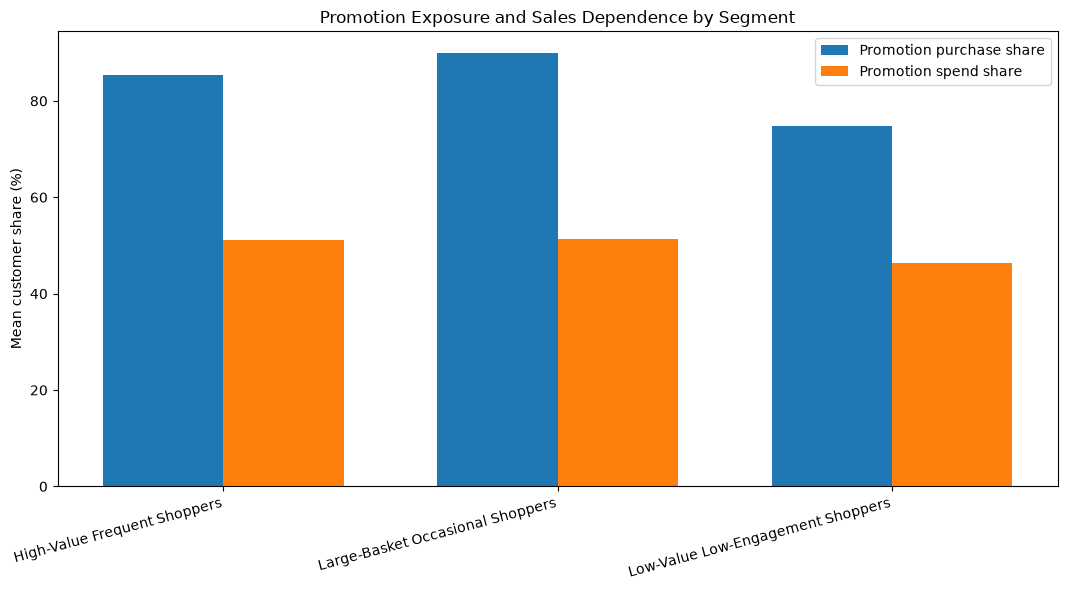

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/09_segment_promotion_dependence.png


In [11]:
# Purpose:
# Compare basket-level promotion exposure with promotional-line
# sales dependence across final segments.

plot_df = (
    segment_promotion_summary[
        [
            "segment_id",
            "segment_name",
            "mean_promotion_purchase_share",
            "mean_promotion_spend_share",
        ]
    ]
    .copy()
)

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x - width / 2,
    plot_df[
        "mean_promotion_purchase_share"
    ] * 100,
    width=width,
    label="Promotion purchase share",
)

ax.bar(
    x + width / 2,
    plot_df[
        "mean_promotion_spend_share"
    ] * 100,
    width=width,
    label="Promotion spend share",
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["segment_name"],
    rotation=15,
    ha="right",
)

ax.set_ylabel("Mean customer share (%)")

ax.set_title(
    "Promotion Exposure and Sales Dependence by Segment"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "09_segment_promotion_dependence.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


## 10. Promotional vs Non-Promotional Basket Value

Basket value is calculated using aggregate basket-classified sales:

- promotional basket value = promotional basket sales / promotional basket count;
- non-promotional basket value = non-promotional basket sales / non-promotional basket count.

This weighting avoids distortion from averaging customer-level averages with very different basket counts.


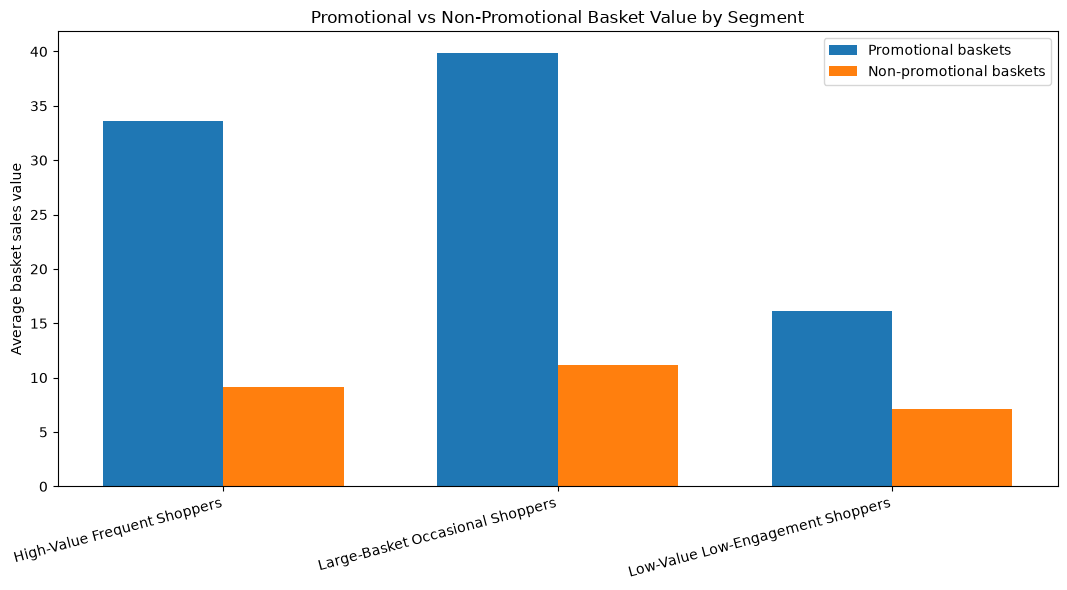

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/10_segment_promo_nonpromo_basket_value.png


In [12]:
# Purpose:
# Compare actual aggregate basket economics across promotional
# and non-promotional shopping occasions.

basket_value_plot = (
    segment_promotion_summary[
        [
            "segment_name",
            "weighted_promo_basket_value",
            "weighted_nonpromo_basket_value",
        ]
    ]
    .copy()
)

x = np.arange(
    len(basket_value_plot)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x - width / 2,
    basket_value_plot[
        "weighted_promo_basket_value"
    ],
    width=width,
    label="Promotional baskets",
)

ax.bar(
    x + width / 2,
    basket_value_plot[
        "weighted_nonpromo_basket_value"
    ],
    width=width,
    label="Non-promotional baskets",
)

ax.set_xticks(x)
ax.set_xticklabels(
    basket_value_plot["segment_name"],
    rotation=15,
    ha="right",
)

ax.set_ylabel("Average basket sales value")

ax.set_title(
    "Promotional vs Non-Promotional Basket Value by Segment"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "10_segment_promo_nonpromo_basket_value.png"
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


## 11. Category-Level Promotional Behavior

Category promotion behavior is calculated from `analytics.customer_category_metrics`.

For each segment × category combination we calculate:

- category sales;
- promotional-line category sales;
- promotional-line sales share;
- category transactions;
- promotional category transactions;
- promotional transaction share;
- customer penetration.

For interpretation, the five largest categories by segment sales are retained. High promotion share in a very small category is not treated as strategically important by itself.


In [13]:
category_promotion = (
    customer_category_metrics
    .merge(
        customer_segments[
            [
                "customer_id",
                "segment_id",
                "segment_name",
            ]
        ],
        on="customer_id",
        how="inner",
        validate="many_to_one",
    )
)

segment_category_promotion = (
    category_promotion
    .groupby(
        [
            "segment_id",
            "segment_name",
            "category",
        ],
        as_index=False,
    )
    .agg(
        category_sales=(
            "category_spend",
            "sum",
        ),
        category_promo_line_sales=(
            "category_promo_spend",
            "sum",
        ),
        category_transactions=(
            "category_transactions",
            "sum",
        ),
        category_promo_transactions=(
            "category_promo_transactions",
            "sum",
        ),
        purchasing_customers=(
            "customer_id",
            "nunique",
        ),
    )
)

segment_customer_counts = (
    customer_segments
    .groupby(
        [
            "segment_id",
            "segment_name",
        ],
        as_index=False,
    )
    .agg(
        segment_customers=(
            "customer_id",
            "size",
        )
    )
)

segment_category_promotion = (
    segment_category_promotion
    .merge(
        segment_customer_counts,
        on=[
            "segment_id",
            "segment_name",
        ],
        how="left",
        validate="many_to_one",
    )
)

segment_category_promotion[
    "category_promo_spend_share"
] = np.where(
    segment_category_promotion[
        "category_sales"
    ] > 0,
    (
        segment_category_promotion[
            "category_promo_line_sales"
        ]
        / segment_category_promotion[
            "category_sales"
        ]
    ),
    np.nan,
)

segment_category_promotion[
    "category_promo_transaction_share"
] = np.where(
    segment_category_promotion[
        "category_transactions"
    ] > 0,
    (
        segment_category_promotion[
            "category_promo_transactions"
        ]
        / segment_category_promotion[
            "category_transactions"
        ]
    ),
    np.nan,
)

segment_category_promotion[
    "customer_penetration"
] = (
    segment_category_promotion[
        "purchasing_customers"
    ]
    / segment_category_promotion[
        "segment_customers"
    ]
)

segment_category_promotion = (
    segment_category_promotion
    .sort_values(
        [
            "segment_id",
            "category_sales",
            "category_transactions",
            "category",
        ],
        ascending=[
            True,
            False,
            False,
            True,
        ],
    )
)

segment_category_promotion[
    "sales_rank"
] = (
    segment_category_promotion
    .groupby("segment_id")
    .cumcount()
    + 1
)

top_segment_promo_categories = (
    segment_category_promotion[
        segment_category_promotion[
            "sales_rank"
        ] <= 5
    ]
    .copy()
)

display(top_segment_promo_categories)


,segment_id,segment_name,category,category_sales,category_promo_line_sales,category_transactions,category_promo_transactions,purchasing_customers,segment_customers,category_promo_spend_share,category_promo_transaction_share,customer_penetration,sales_rank
77,1,High-Value Frequent Shoppers,COUPON/MISC ITEMS,"542,555.4200","514,824.0100",22630,19350,968,1007,0.9489,0.8551,0.9613,1
269,1,High-Value Frequent Shoppers,SOFT DRINKS,"237,213.6300","160,608.1000",52543,35919,1004,1007,0.6771,0.6836,0.9970,2
24,1,High-Value Frequent Shoppers,BEEF,"221,253.6700","108,645.3700",26166,14313,980,1007,0.4910,0.5470,0.9732,3
122,1,High-Value Frequent Shoppers,FLUID MILK PRODUCTS,"149,879.7000","67,149.7900",49425,25183,1005,1007,0.4480,0.5095,0.9980,4
51,1,High-Value Frequent Shoppers,CHEESE,"135,886.4000","102,324.6100",33676,28316,1005,1007,0.7530,0.8408,0.9980,5
328,2,Large-Basket Occasional Shoppers,BEEF,"76,776.1000","37,784.2200",8472,4463,831,902,0.4921,0.5268,0.9213,1
381,2,Large-Basket Occasional Shoppers,COUPON/MISC ITEMS,"75,358.1900","68,683.5500",3626,2721,682,902,0.9114,0.7504,0.7561,2
573,2,Large-Basket Occasional Shoppers,SOFT DRINKS,"69,981.3200","47,967.3500",13212,9208,884,902,0.6854,0.6969,0.9800,3
355,2,Large-Basket Occasional Shoppers,CHEESE,"46,384.9500","34,463.7700",10891,9087,877,902,0.7430,0.8344,0.9723,4
427,2,Large-Basket Occasional Shoppers,FLUID MILK PRODUCTS,"43,742.4900","18,670.4700",15071,7260,889,902,0.4268,0.4817,0.9856,5


In [14]:
# Reconcile category promotional-line sales to segment-level
# promotional-line sales.

category_segment_reconciliation = (
    segment_category_promotion
    .groupby(
        [
            "segment_id",
            "segment_name",
        ],
        as_index=False,
    )
    .agg(
        category_sales=(
            "category_sales",
            "sum",
        ),
        category_promo_line_sales=(
            "category_promo_line_sales",
            "sum",
        ),
    )
    .merge(
        segment_promotion_summary[
            [
                "segment_id",
                "segment_name",
                "total_sales",
                "promo_line_sales",
            ]
        ],
        on=[
            "segment_id",
            "segment_name",
        ],
        how="left",
        validate="one_to_one",
    )
)

category_segment_reconciliation[
    "sales_difference"
] = (
    category_segment_reconciliation[
        "category_sales"
    ]
    - category_segment_reconciliation[
        "total_sales"
    ]
)

category_segment_reconciliation[
    "promo_difference"
] = (
    category_segment_reconciliation[
        "category_promo_line_sales"
    ]
    - category_segment_reconciliation[
        "promo_line_sales"
    ]
)

assert (
    category_segment_reconciliation[
        "sales_difference"
    ].abs().max()
    <= 0.01
)

assert (
    category_segment_reconciliation[
        "promo_difference"
    ].abs().max()
    <= 0.01
)

print(
    "Category-level promotion reconciliation: PASS"
)


Category-level promotion reconciliation: PASS


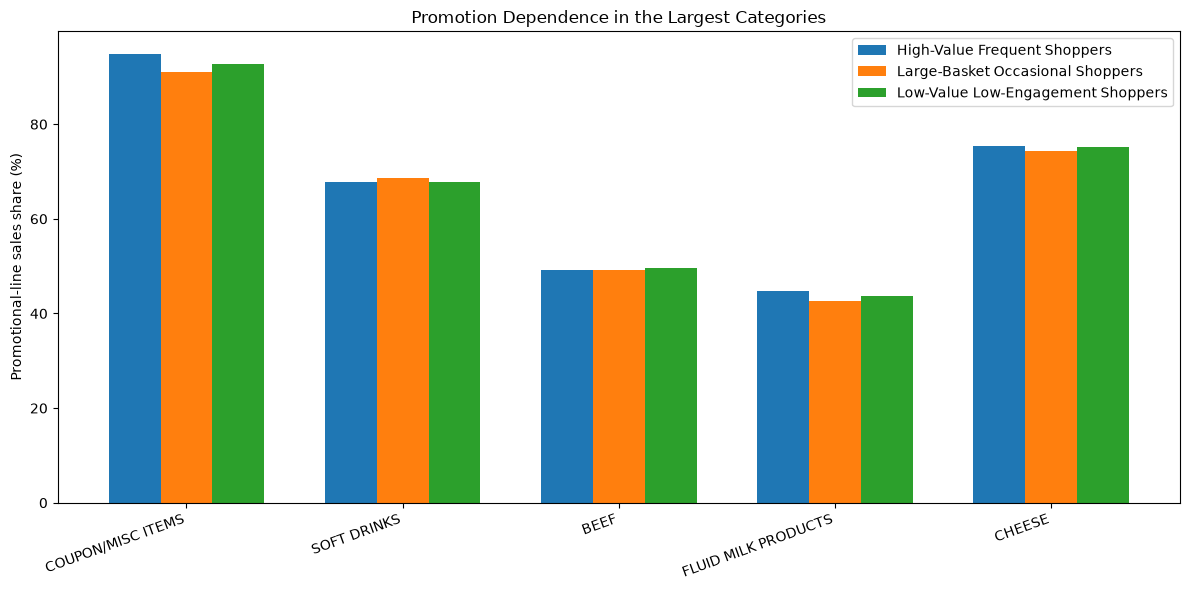

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/11_top_category_promotion_behavior.png


In [15]:
# Use the five largest overall categories to compare promotional
# line-sales dependence consistently across all three segments.

overall_category_sales = (
    customer_category_metrics
    .groupby(
        "category",
        as_index=False,
    )
    .agg(
        category_sales=(
            "category_spend",
            "sum",
        )
    )
    .sort_values(
        [
            "category_sales",
            "category",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

top_overall_categories = (
    overall_category_sales
    .head(5)["category"]
    .tolist()
)

category_comparison_plot = (
    segment_category_promotion[
        segment_category_promotion[
            "category"
        ].isin(
            top_overall_categories
        )
    ][
        [
            "segment_id",
            "segment_name",
            "category",
            "category_promo_spend_share",
        ]
    ]
    .copy()
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

x = np.arange(
    len(top_overall_categories)
)

width = 0.24

for i, (
    segment_id,
    segment_name,
) in enumerate(
    customer_segments[
        [
            "segment_id",
            "segment_name",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "segment_id"
    )
    .itertuples(
        index=False,
        name=None,
    )
):
    subset = (
        category_comparison_plot[
            category_comparison_plot[
                "segment_id"
            ] == segment_id
        ]
        .set_index("category")
        .reindex(
            top_overall_categories
        )
    )

    ax.bar(
        x + (i - 1) * width,
        subset[
            "category_promo_spend_share"
        ].to_numpy() * 100,
        width=width,
        label=segment_name,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    top_overall_categories,
    rotation=20,
    ha="right",
)

ax.set_ylabel(
    "Promotional-line sales share (%)"
)

ax.set_title(
    "Promotion Dependence in the Largest Categories"
)

ax.legend()

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "11_top_category_promotion_behavior.png"
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


In [16]:
# Export Phase 8.2 analytical outputs.

segment_promotion_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "13_segment_promotion_summary.csv",
    index=False,
)

segment_category_promotion.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "13_segment_category_promotion.csv",
    index=False,
)

top_segment_promo_categories.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "13_top_segment_promo_categories.csv",
    index=False,
)

category_segment_reconciliation.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "13_category_promotion_reconciliation.csv",
    index=False,
)

print("SEGMENT PROMOTION SUMMARY")

summary_columns = [
    "segment_id",
    "segment_name",
    "customers",
    "customer_share",
    "revenue_share",
    "mean_purchase_frequency",
    "mean_promotion_purchase_share",
    "mean_promotion_spend_share",
    "promo_basket_sales_share",
    "weighted_promo_basket_value",
    "weighted_nonpromo_basket_value",
    "promo_vs_nonpromo_basket_value_ratio",
]

print(
    segment_promotion_summary[
        summary_columns
    ].to_string(
        index=False,
        formatters={
            "customer_share": (
                lambda x: f"{x:.2%}"
            ),
            "revenue_share": (
                lambda x: f"{x:.2%}"
            ),
            "mean_purchase_frequency": (
                lambda x: f"{x:.2f}"
            ),
            "mean_promotion_purchase_share": (
                lambda x: f"{x:.2%}"
            ),
            "mean_promotion_spend_share": (
                lambda x: f"{x:.2%}"
            ),
            "promo_basket_sales_share": (
                lambda x: f"{x:.2%}"
            ),
            "weighted_promo_basket_value": (
                lambda x: f"{x:,.2f}"
            ),
            "weighted_nonpromo_basket_value": (
                lambda x: f"{x:,.2f}"
            ),
            "promo_vs_nonpromo_basket_value_ratio": (
                lambda x: f"{x:.2f}x"
            ),
        },
    )
)

print()
print("TOP PROMOTION CATEGORIES BY SEGMENT")

for segment_id in sorted(
    top_segment_promo_categories[
        "segment_id"
    ].unique()
):
    subset = (
        top_segment_promo_categories[
            top_segment_promo_categories[
                "segment_id"
            ] == segment_id
        ]
        .copy()
    )

    segment_name = (
        subset[
            "segment_name"
        ].iloc[0]
    )

    print()
    print(
        f"{segment_id} | "
        f"{segment_name}"
    )

    print(
        subset[
            [
                "sales_rank",
                "category",
                "category_sales",
                "category_promo_spend_share",
                "category_promo_transaction_share",
                "customer_penetration",
            ]
        ].to_string(
            index=False,
            formatters={
                "category_sales": (
                    lambda x: f"{x:,.2f}"
                ),
                "category_promo_spend_share": (
                    lambda x: f"{x:.2%}"
                ),
                "category_promo_transaction_share": (
                    lambda x: f"{x:.2%}"
                ),
                "customer_penetration": (
                    lambda x: f"{x:.2%}"
                ),
            },
        )
    )


SEGMENT PROMOTION SUMMARY
 segment_id                      segment_name  customers customer_share revenue_share mean_purchase_frequency mean_promotion_purchase_share mean_promotion_spend_share promo_basket_sales_share weighted_promo_basket_value weighted_nonpromo_basket_value promo_vs_nonpromo_basket_value_ratio
          1      High-Value Frequent Shoppers       1007         40.28%        73.52%                    9.17                        85.37%                     51.21%                   95.11%                       33.62                           9.11                                3.69x
          2  Large-Basket Occasional Shoppers        902         36.08%        21.49%                    2.94                        89.94%                     51.36%                   96.71%                       39.86                          11.20                                3.56x
          3 Low-Value Low-Engagement Shoppers        591         23.64%         4.99%                    3.14 

## 12. Exploratory Statistical Validation

Statistical testing is deliberately limited.

The tests evaluate whether selected behavioral distributions differ across the final segments. Because the segments were constructed from the same customer behavioral dataset, results are interpreted as **exploratory validation**, not independent causal evidence.

### Test 1

Kruskal-Wallis test of `average_items_per_basket` across segments.

### Test 2

Kruskal-Wallis test of `promotion_spend_share` across segments.

### Test 3

A chi-square test of `segment_name × top_category` is performed only if expected-count assumptions are adequate.

Significance level:

`alpha = 0.05`

For the Kruskal-Wallis tests, descriptive medians, interquartile ranges and epsilon-squared effect size are reported so statistical significance is not interpreted without business magnitude.


In [17]:
from scipy.stats import kruskal, chi2_contingency

ALPHA = 0.05

segment_order = (
    customer_segments[
        [
            "segment_id",
            "segment_name",
        ]
    ]
    .drop_duplicates()
    .sort_values("segment_id")
)

def segment_distribution_summary(
    df: pd.DataFrame,
    metric: str,
) -> pd.DataFrame:
    return (
        df
        .groupby(
            [
                "segment_id",
                "segment_name",
            ],
            as_index=False,
        )
        .agg(
            n=(metric, "count"),
            mean=(metric, "mean"),
            median=(metric, "median"),
            q25=(
                metric,
                lambda x: x.quantile(0.25),
            ),
            q75=(
                metric,
                lambda x: x.quantile(0.75),
            ),
        )
        .sort_values("segment_id")
        .reset_index(drop=True)
    )

def epsilon_squared(
    h_statistic: float,
    n: int,
    k: int,
) -> float:
    value = (
        h_statistic - k + 1
    ) / (
        n - k
    )

    return max(
        0.0,
        float(value),
    )


### Test 1 — Average items per basket

In [18]:
items_summary = (
    segment_distribution_summary(
        promotion_customer,
        "average_items_per_basket",
    )
)

items_groups = [
    promotion_customer.loc[
        promotion_customer[
            "segment_id"
        ] == segment_id,
        "average_items_per_basket",
    ].dropna()
    for segment_id
    in segment_order[
        "segment_id"
    ]
]

items_test = kruskal(
    *items_groups
)

items_epsilon_sq = epsilon_squared(
    items_test.statistic,
    n=sum(
        len(group)
        for group in items_groups
    ),
    k=len(items_groups),
)

display(items_summary)

print(
    "TEST 1 — AVERAGE ITEMS PER BASKET"
)

print(
    f"Kruskal-Wallis H: "
    f"{items_test.statistic:.4f}"
)

print(
    f"p-value: "
    f"{items_test.pvalue:.6g}"
)

print(
    f"Epsilon-squared: "
    f"{items_epsilon_sq:.4f}"
)

print(
    "Decision at alpha=0.05: "
    + (
        "reject equal-distribution null"
        if items_test.pvalue < ALPHA
        else "do not reject equal-distribution null"
    )
)

print()
print(
    items_summary.to_string(
        index=False,
        formatters={
            "mean": lambda x: f"{x:.2f}",
            "median": lambda x: f"{x:.2f}",
            "q25": lambda x: f"{x:.2f}",
            "q75": lambda x: f"{x:.2f}",
        },
    )
)


,segment_id,segment_name,n,mean,median,q25,q75
0,1,High-Value Frequent Shoppers,1007,13.5989,12.1293,8.8715,16.8609
1,2,Large-Basket Occasional Shoppers,902,17.5705,15.5944,11.6186,21.2186
2,3,Low-Value Low-Engagement Shoppers,591,6.8962,6.3494,4.8335,8.2500


TEST 1 — AVERAGE ITEMS PER BASKET
Kruskal-Wallis H: 939.1574
p-value: 1.16028e-204
Epsilon-squared: 0.3753
Decision at alpha=0.05: reject equal-distribution null

 segment_id                      segment_name    n  mean median   q25   q75
          1      High-Value Frequent Shoppers 1007 13.60  12.13  8.87 16.86
          2  Large-Basket Occasional Shoppers  902 17.57  15.59 11.62 21.22
          3 Low-Value Low-Engagement Shoppers  591  6.90   6.35  4.83  8.25


### Test 2 — Promotion spend share

In [19]:
promotion_spend_summary = (
    segment_distribution_summary(
        promotion_customer,
        "promotion_spend_share",
    )
)

promotion_spend_groups = [
    promotion_customer.loc[
        promotion_customer[
            "segment_id"
        ] == segment_id,
        "promotion_spend_share",
    ].dropna()
    for segment_id
    in segment_order[
        "segment_id"
    ]
]

promotion_spend_test = kruskal(
    *promotion_spend_groups
)

promotion_spend_epsilon_sq = (
    epsilon_squared(
        promotion_spend_test.statistic,
        n=sum(
            len(group)
            for group
            in promotion_spend_groups
        ),
        k=len(
            promotion_spend_groups
        ),
    )
)

display(promotion_spend_summary)

print(
    "TEST 2 — PROMOTION SPEND SHARE"
)

print(
    f"Kruskal-Wallis H: "
    f"{promotion_spend_test.statistic:.4f}"
)

print(
    f"p-value: "
    f"{promotion_spend_test.pvalue:.6g}"
)

print(
    f"Epsilon-squared: "
    f"{promotion_spend_epsilon_sq:.4f}"
)

print(
    "Decision at alpha=0.05: "
    + (
        "reject equal-distribution null"
        if promotion_spend_test.pvalue
        < ALPHA
        else
        "do not reject equal-distribution null"
    )
)

print()
print(
    promotion_spend_summary.to_string(
        index=False,
        formatters={
            "mean": lambda x: f"{x:.2%}",
            "median": lambda x: f"{x:.2%}",
            "q25": lambda x: f"{x:.2%}",
            "q75": lambda x: f"{x:.2%}",
        },
    )
)


,segment_id,segment_name,n,mean,median,q25,q75
0,1,High-Value Frequent Shoppers,1007,0.5121,0.5124,0.4429,0.5798
1,2,Large-Basket Occasional Shoppers,902,0.5136,0.5129,0.4422,0.5843
2,3,Low-Value Low-Engagement Shoppers,591,0.4635,0.4609,0.3702,0.5540


TEST 2 — PROMOTION SPEND SHARE
Kruskal-Wallis H: 70.6540
p-value: 4.5464e-16
Epsilon-squared: 0.0275
Decision at alpha=0.05: reject equal-distribution null

 segment_id                      segment_name    n   mean median    q25    q75
          1      High-Value Frequent Shoppers 1007 51.21% 51.24% 44.29% 57.98%
          2  Large-Basket Occasional Shoppers  902 51.36% 51.29% 44.22% 58.43%
          3 Low-Value Low-Engagement Shoppers  591 46.35% 46.09% 37.02% 55.40%


### Test 3 Eligibility — Segment × Top Category

Before running chi-square, expected cell counts are assessed directly from the contingency-table margins.

The test is considered adequate only when:

- no expected count is below 1; and
- no more than 20% of expected cells are below 5.

If these conditions fail, the third test is omitted rather than forcing categories into arbitrary groups solely to obtain significance.


In [20]:
top_category_contingency = pd.crosstab(
    promotion_customer[
        "segment_name"
    ],
    promotion_customer[
        "top_category"
    ],
)

observed = (
    top_category_contingency
    .to_numpy(
        dtype=float
    )
)

row_totals = observed.sum(
    axis=1,
    keepdims=True,
)

column_totals = observed.sum(
    axis=0,
    keepdims=True,
)

grand_total = observed.sum()

expected_counts = (
    row_totals
    @ column_totals
    / grand_total
)

expected_min = (
    expected_counts.min()
)

expected_below_1 = int(
    (
        expected_counts < 1
    ).sum()
)

expected_below_5 = int(
    (
        expected_counts < 5
    ).sum()
)

expected_cell_count = int(
    expected_counts.size
)

expected_below_5_share = (
    expected_below_5
    / expected_cell_count
)

chi_square_adequate = (
    expected_min >= 1
    and expected_below_5_share <= 0.20
)

chi_square_assumption_summary = (
    pd.DataFrame(
        {
            "metric": [
                "Segments",
                "Top-category levels",
                "Expected cells",
                "Minimum expected count",
                "Expected cells below 1",
                "Expected cells below 5",
                "Share of expected cells below 5",
                "Assumptions adequate",
            ],
            "value": [
                top_category_contingency.shape[0],
                top_category_contingency.shape[1],
                expected_cell_count,
                expected_min,
                expected_below_1,
                expected_below_5,
                expected_below_5_share,
                chi_square_adequate,
            ],
        }
    )
)

display(
    chi_square_assumption_summary
)

print(
    "TEST 3 — CHI-SQUARE ELIGIBILITY"
)

print(
    f"Top-category levels: "
    f"{top_category_contingency.shape[1]}"
)

print(
    f"Minimum expected count: "
    f"{expected_min:.4f}"
)

print(
    f"Expected cells below 1: "
    f"{expected_below_1}"
)

print(
    f"Expected cells below 5: "
    f"{expected_below_5} "
    f"of {expected_cell_count} "
    f"({expected_below_5_share:.2%})"
)

print(
    f"Assumptions adequate: "
    f"{chi_square_adequate}"
)


,metric,value
0,Segments,3
1,Top-category levels,143
2,Expected cells,429
3,Minimum expected count,0.2364
4,Expected cells below 1,240
5,Expected cells below 5,366
6,Share of expected cells below 5,0.8531
7,Assumptions adequate,False


TEST 3 — CHI-SQUARE ELIGIBILITY
Top-category levels: 143
Minimum expected count: 0.2364
Expected cells below 1: 240
Expected cells below 5: 366 of 429 (85.31%)
Assumptions adequate: False


In [21]:
# Run Test 3 only when the expected-count diagnostic passes.

chi_square_result = None

if chi_square_adequate:
    (
        chi2_statistic,
        chi2_pvalue,
        chi2_dof,
        chi2_expected,
    ) = chi2_contingency(
        top_category_contingency
    )

    n = observed.sum()

    min_dimension = min(
        top_category_contingency.shape[0] - 1,
        top_category_contingency.shape[1] - 1,
    )

    cramers_v = np.sqrt(
        (chi2_statistic / n)
        / min_dimension
    )

    chi_square_result = {
        "test": (
            "Chi-square: segment × top_category"
        ),
        "statistic": chi2_statistic,
        "p_value": chi2_pvalue,
        "effect_size": cramers_v,
        "effect_size_name": "Cramer's V",
        "executed": True,
    }

    print(
        "TEST 3 — SEGMENT × TOP CATEGORY"
    )

    print(
        f"Chi-square statistic: "
        f"{chi2_statistic:.4f}"
    )

    print(
        f"Degrees of freedom: "
        f"{chi2_dof}"
    )

    print(
        f"p-value: "
        f"{chi2_pvalue:.6g}"
    )

    print(
        f"Cramer's V: "
        f"{cramers_v:.4f}"
    )
else:
    print(
        "TEST 3 OMITTED"
    )

    print(
        "Reason: expected-count assumptions "
        "are not adequate."
    )


TEST 3 OMITTED
Reason: expected-count assumptions are not adequate.


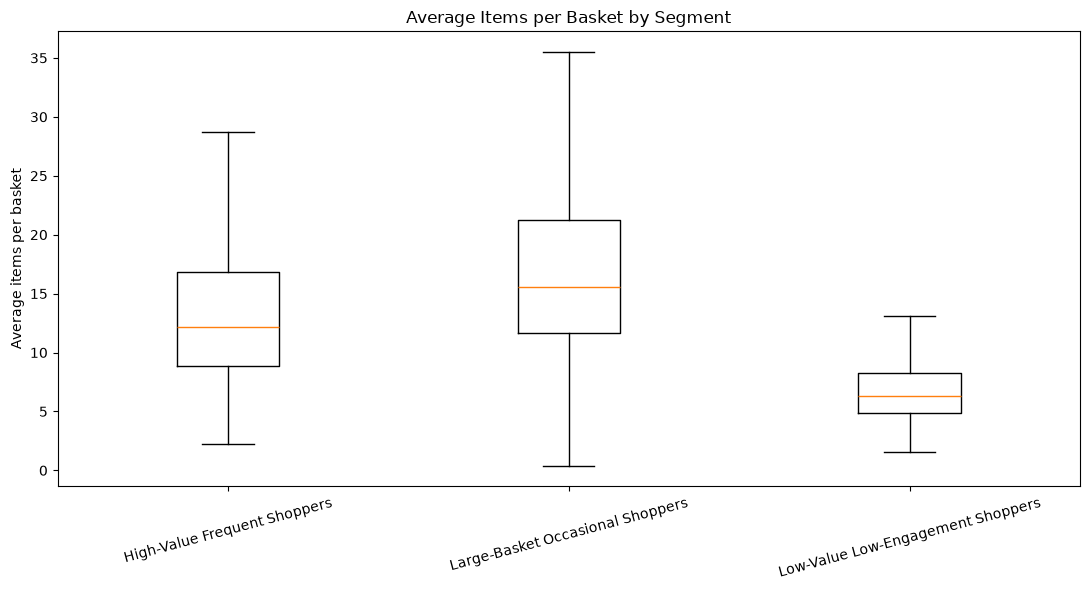

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/12_average_items_per_basket_by_segment.png


In [22]:
# Purpose:
# Show the customer-level distribution underlying Test 1.

items_plot_data = [
    promotion_customer.loc[
        promotion_customer[
            "segment_id"
        ] == segment_id,
        "average_items_per_basket",
    ].dropna().to_numpy()
    for segment_id
    in segment_order[
        "segment_id"
    ]
]

items_labels = (
    segment_order[
        "segment_name"
    ].tolist()
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.boxplot(
    items_plot_data,
    tick_labels=items_labels,
    showfliers=False,
)

ax.set_ylabel(
    "Average items per basket"
)

ax.set_title(
    "Average Items per Basket by Segment"
)

ax.tick_params(
    axis="x",
    labelrotation=15,
)

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "12_average_items_per_basket_by_segment.png"
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


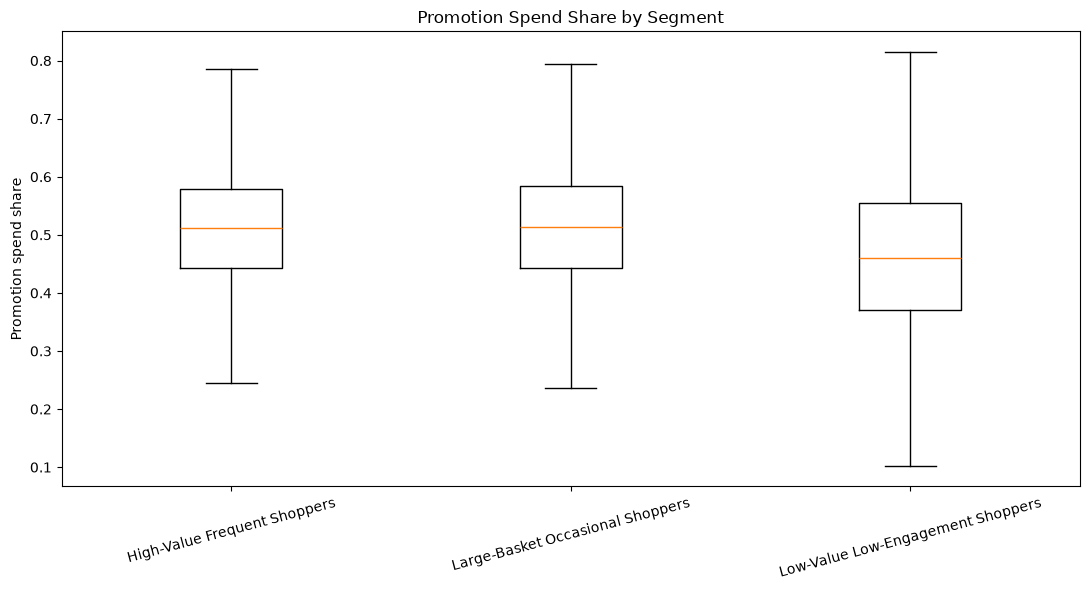

Saved figure: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/figures/13_promotion_spend_share_by_segment.png


In [23]:
# Purpose:
# Show the customer-level distribution underlying Test 2.

promo_share_plot_data = [
    promotion_customer.loc[
        promotion_customer[
            "segment_id"
        ] == segment_id,
        "promotion_spend_share",
    ].dropna().to_numpy()
    for segment_id
    in segment_order[
        "segment_id"
    ]
]

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.boxplot(
    promo_share_plot_data,
    tick_labels=items_labels,
    showfliers=False,
)

ax.set_ylabel(
    "Promotion spend share"
)

ax.set_title(
    "Promotion Spend Share by Segment"
)

ax.tick_params(
    axis="x",
    labelrotation=15,
)

fig.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "13_promotion_spend_share_by_segment.png"
)

fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")


In [24]:
# Export statistical validation results.

items_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "14_average_items_segment_summary.csv",
    index=False,
)

promotion_spend_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "14_promotion_spend_share_segment_summary.csv",
    index=False,
)

chi_square_assumption_summary.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "14_chi_square_assumption_check.csv",
    index=False,
)

statistical_results = [
    {
        "test": (
            "Kruskal-Wallis: "
            "average_items_per_basket"
        ),
        "statistic": items_test.statistic,
        "p_value": items_test.pvalue,
        "effect_size": items_epsilon_sq,
        "effect_size_name": (
            "epsilon_squared"
        ),
        "executed": True,
    },
    {
        "test": (
            "Kruskal-Wallis: "
            "promotion_spend_share"
        ),
        "statistic": (
            promotion_spend_test.statistic
        ),
        "p_value": (
            promotion_spend_test.pvalue
        ),
        "effect_size": (
            promotion_spend_epsilon_sq
        ),
        "effect_size_name": (
            "epsilon_squared"
        ),
        "executed": True,
    },
]

if chi_square_result is not None:
    statistical_results.append(
        chi_square_result
    )

statistical_results = pd.DataFrame(
    statistical_results
)

statistical_results.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "14_statistical_validation_results.csv",
    index=False,
)

print("STATISTICAL VALIDATION SUMMARY")

print(
    statistical_results.to_string(
        index=False,
        formatters={
            "statistic": (
                lambda x: f"{x:.4f}"
            ),
            "p_value": (
                lambda x: f"{x:.6g}"
            ),
            "effect_size": (
                lambda x: f"{x:.4f}"
            ),
        },
    )
)

print()
print(
    f"Executed statistical tests: "
    f"{len(statistical_results)}"
)


STATISTICAL VALIDATION SUMMARY
                                    test statistic      p_value effect_size effect_size_name  executed
Kruskal-Wallis: average_items_per_basket  939.1574 1.16028e-204      0.3753  epsilon_squared      True
   Kruskal-Wallis: promotion_spend_share   70.6540   4.5464e-16      0.0275  epsilon_squared      True

Executed statistical tests: 2


## 13. Promotion Analysis Interpretation

### Statistical validation

The exploratory tests support two different conclusions.

**Basket-size behavior differs materially across segments.**

`average_items_per_basket` differs strongly across the three segments:

- Large-Basket Occasional Shoppers: median 15.59 items;
- High-Value Frequent Shoppers: median 12.13 items;
- Low-Value Low-Engagement Shoppers: median 6.35 items.

The Kruskal-Wallis result is statistically significant and epsilon-squared is 0.3753, confirming that the descriptive basket-size separation is substantial.

**Promotion spend-share differences are statistically detectable but much smaller in magnitude.**

Median promotion spend share is:

- 51.24% for High-Value Frequent Shoppers;
- 51.29% for Large-Basket Occasional Shoppers;
- 46.09% for Low-Value Low-Engagement Shoppers.

Although the Kruskal-Wallis test is statistically significant, epsilon-squared is only 0.0275. High-Value Frequent and Large-Basket Occasional customers are therefore nearly indistinguishable on promotional-line sales share despite substantial differences in frequency, basket size and customer value.

The chi-square test of segment × top category is omitted because expected-count assumptions are severely violated: 85.31% of expected cells are below five. Categories are not merged artificially solely to force statistical significance.

All statistical results are exploratory validation of observed behavior and are not causal evidence.


## 14. Major-Category Promotion Consistency

For the largest merchandise categories, promotional-line sales dependence is compared across segments to determine whether the pattern is primarily segment-specific or category-specific.

`COUPON/MISC ITEMS` remains in source reconciliation but is excluded from strategic merchandise interpretation.


In [25]:
major_category_comparison = (
    segment_category_promotion[
        segment_category_promotion[
            "category"
        ].isin(top_overall_categories)
    ][
        [
            "segment_id",
            "segment_name",
            "category",
            "category_sales",
            "category_promo_spend_share",
        ]
    ]
    .copy()
)

major_category_range = (
    major_category_comparison
    .groupby(
        "category",
        as_index=False,
    )
    .agg(
        total_segment_category_sales=(
            "category_sales",
            "sum",
        ),
        minimum_promo_spend_share=(
            "category_promo_spend_share",
            "min",
        ),
        maximum_promo_spend_share=(
            "category_promo_spend_share",
            "max",
        ),
        mean_promo_spend_share=(
            "category_promo_spend_share",
            "mean",
        ),
    )
)

major_category_range[
    "cross_segment_range_pp"
] = (
    major_category_range[
        "maximum_promo_spend_share"
    ]
    - major_category_range[
        "minimum_promo_spend_share"
    ]
) * 100

major_category_range = (
    major_category_range
    .sort_values(
        "total_segment_category_sales",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(major_category_range)


,category,total_segment_category_sales,minimum_promo_spend_share,maximum_promo_spend_share,mean_promo_spend_share,cross_segment_range_pp
0,COUPON/MISC ITEMS,"639,878.4600",0.9114,0.9489,0.9290,3.7460
1,SOFT DRINKS,"327,645.2100",0.6771,0.6854,0.6804,0.8370
2,BEEF,"312,103.2200",0.4910,0.4961,0.4931,0.5007
3,FLUID MILK PRODUCTS,"205,356.0500",0.4268,0.4480,0.4370,2.1198
4,CHEESE,"189,528.1800",0.7430,0.7530,0.7491,1.0021


In [26]:
# Export the category consistency diagnostic.

major_category_range.to_csv(
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "15_major_category_promotion_consistency.csv",
    index=False,
)

print("MAJOR CATEGORY PROMOTION CONSISTENCY")

print(
    major_category_range.to_string(
        index=False,
        formatters={
            "total_segment_category_sales": (
                lambda x: f"{x:,.2f}"
            ),
            "minimum_promo_spend_share": (
                lambda x: f"{x:.2%}"
            ),
            "maximum_promo_spend_share": (
                lambda x: f"{x:.2%}"
            ),
            "mean_promo_spend_share": (
                lambda x: f"{x:.2%}"
            ),
            "cross_segment_range_pp": (
                lambda x: f"{x:.2f} pp"
            ),
        },
    )
)


MAJOR CATEGORY PROMOTION CONSISTENCY
           category total_segment_category_sales minimum_promo_spend_share maximum_promo_spend_share mean_promo_spend_share cross_segment_range_pp
  COUPON/MISC ITEMS                   639,878.46                    91.14%                    94.89%                 92.90%                3.75 pp
        SOFT DRINKS                   327,645.21                    67.71%                    68.54%                 68.04%                0.84 pp
               BEEF                   312,103.22                    49.10%                    49.61%                 49.31%                0.50 pp
FLUID MILK PRODUCTS                   205,356.05                    42.68%                    44.80%                 43.70%                2.12 pp
             CHEESE                   189,528.18                    74.30%                    75.30%                 74.91%                1.00 pp


## 15. Candidate Business Implications

These are **candidate implications**, not final recommendations. Final insight and recommendation selection occurs only after all consumer, segmentation and promotion findings are reviewed together.

### Candidate Implication 1 — Promotion exposure should not be treated as the same thing as promotion sales dependence

**Observation**  
Large-Basket Occasional Shoppers have the highest promotion purchase share at 89.94%, compared with 85.37% for High-Value Frequent Shoppers, yet their mean promotional-line spend shares are almost identical at 51.36% and 51.21%.

**Evidence**  
The Kruskal-Wallis test for promotion spend share is statistically significant, but epsilon-squared is only 0.0275. Median promotion spend share is 51.29% versus 51.24% for these two segments.

**Business implication**  
A higher rate of baskets containing promotional items does not necessarily indicate materially greater dependence on promotional-line sales. Future campaign strategy should therefore distinguish basket exposure from actual promotional sales reliance rather than applying one promotion-sensitivity label.

**Phase 9 consideration**  
Evaluate whether this distinction supports a targeted promotion-efficiency recommendation without making margin or causal-lift claims.

---

### Candidate Implication 2 — Shopping-occasion size is a much stronger segment differentiator than promotion spend share

**Observation**  
Large-Basket Occasional Shoppers purchase materially more items per basket, while Low-Value Low-Engagement Shoppers have much smaller shopping occasions.

**Evidence**  
Median average items per basket are 15.59, 12.13 and 6.35 for Large-Basket Occasional, High-Value Frequent and Low-Value Low-Engagement Shoppers respectively. The exploratory Kruskal-Wallis epsilon-squared is 0.3753.

Promotional baskets are also larger than non-promotional baskets within all three segments, with observed aggregate basket-value ratios of 3.56x, 3.69x and 2.26x respectively; this association is descriptive and not causal.

**Business implication**  
The segments differ more clearly in shopping-mission scale and engagement pattern than in promotional-line sales share. Commercial interpretation should preserve this behavioral distinction rather than defining the segments primarily through discount behavior.

**Phase 9 consideration**  
Evaluate whether the Large-Basket Occasional segment supports a growth-oriented action focused on shopping occasions, category breadth or repeat frequency.

---

### Candidate Implication 3 — Promotion intensity in major merchandise categories appears relatively consistent across segments

**Observation**  
For several large merchandise categories, promotional-line sales shares are similar across the three segments even though the segments differ materially in value, frequency and basket size.

**Evidence**  
Soft Drinks, Beef, Fluid Milk Products and Cheese show broadly similar promotional-line sales shares across segments, while their absolute promotional intensity differs substantially by category. `COUPON/MISC ITEMS` is excluded from strategic interpretation because it is a source pseudo-category.

**Business implication**  
For major categories, promotion behavior may reflect category-level merchandising patterns at least as much as segment identity. A future category-specific action should therefore use both segment and category evidence rather than assuming every promotion difference is customer-segment driven.

**Phase 9 consideration**  
Review quantified cross-segment category ranges before deciding whether a category-targeted promotion recommendation is strong enough to become one of the final three actions.


In [27]:
# Export candidate implications for Phase 9 review.

insights_dir = (
    PROJECT_ROOT
    / "outputs"
    / "insights"
)

insights_dir.mkdir(
    parents=True,
    exist_ok=True,
)

candidate_implications_path = (
    insights_dir
    / "02_promotion_candidate_business_implications.md"
)

candidate_implications_text = r'''## 15. Candidate Business Implications

These are **candidate implications**, not final recommendations. Final insight and recommendation selection occurs only after all consumer, segmentation and promotion findings are reviewed together.

### Candidate Implication 1 — Promotion exposure should not be treated as the same thing as promotion sales dependence

**Observation**  
Large-Basket Occasional Shoppers have the highest promotion purchase share at 89.94%, compared with 85.37% for High-Value Frequent Shoppers, yet their mean promotional-line spend shares are almost identical at 51.36% and 51.21%.

**Evidence**  
The Kruskal-Wallis test for promotion spend share is statistically significant, but epsilon-squared is only 0.0275. Median promotion spend share is 51.29% versus 51.24% for these two segments.

**Business implication**  
A higher rate of baskets containing promotional items does not necessarily indicate materially greater dependence on promotional-line sales. Future campaign strategy should therefore distinguish basket exposure from actual promotional sales reliance rather than applying one promotion-sensitivity label.

**Phase 9 consideration**  
Evaluate whether this distinction supports a targeted promotion-efficiency recommendation without making margin or causal-lift claims.

---

### Candidate Implication 2 — Shopping-occasion size is a much stronger segment differentiator than promotion spend share

**Observation**  
Large-Basket Occasional Shoppers purchase materially more items per basket, while Low-Value Low-Engagement Shoppers have much smaller shopping occasions.

**Evidence**  
Median average items per basket are 15.59, 12.13 and 6.35 for Large-Basket Occasional, High-Value Frequent and Low-Value Low-Engagement Shoppers respectively. The exploratory Kruskal-Wallis epsilon-squared is 0.3753.

Promotional baskets are also larger than non-promotional baskets within all three segments, with observed aggregate basket-value ratios of 3.56x, 3.69x and 2.26x respectively; this association is descriptive and not causal.

**Business implication**  
The segments differ more clearly in shopping-mission scale and engagement pattern than in promotional-line sales share. Commercial interpretation should preserve this behavioral distinction rather than defining the segments primarily through discount behavior.

**Phase 9 consideration**  
Evaluate whether the Large-Basket Occasional segment supports a growth-oriented action focused on shopping occasions, category breadth or repeat frequency.

---

### Candidate Implication 3 — Promotion intensity in major merchandise categories appears relatively consistent across segments

**Observation**  
For several large merchandise categories, promotional-line sales shares are similar across the three segments even though the segments differ materially in value, frequency and basket size.

**Evidence**  
Soft Drinks, Beef, Fluid Milk Products and Cheese show broadly similar promotional-line sales shares across segments, while their absolute promotional intensity differs substantially by category. `COUPON/MISC ITEMS` is excluded from strategic interpretation because it is a source pseudo-category.

**Business implication**  
For major categories, promotion behavior may reflect category-level merchandising patterns at least as much as segment identity. A future category-specific action should therefore use both segment and category evidence rather than assuming every promotion difference is customer-segment driven.

**Phase 9 consideration**  
Review quantified cross-segment category ranges before deciding whether a category-targeted promotion recommendation is strong enough to become one of the final three actions.
'''

candidate_implications_path.write_text(
    candidate_implications_text,
    encoding="utf-8",
)

print("PROMOTION CANDIDATE IMPLICATIONS")
print("Candidate implication count: 3")
print(
    f"Saved implications: "
    f"{candidate_implications_path}"
)


PROMOTION CANDIDATE IMPLICATIONS
Candidate implication count: 3
Saved implications: /Users/sudenazcaglar/Developer/fmcg-consumer-growth-insights/outputs/insights/02_promotion_candidate_business_implications.md


## 16. Promotion Analysis Limitations

- Promotion metrics describe observed purchase behavior and do not measure incremental lift.
- Margin and profit data are unavailable; promotion profitability cannot be determined.
- Promotional baskets contain at least one promotional line, so entire-basket sales must not be described as discounted sales.
- Customers with no non-promotional baskets legitimately have no non-promotional average basket value.
- Promotional and non-promotional baskets may represent different shopping missions; their basket-value difference is associative rather than causal.
- Segment × top-category chi-square testing is omitted because expected-count assumptions are not adequate.
- `COUPON/MISC ITEMS` is retained for source reconciliation but should not be treated as a normal merchandise category in strategic interpretation.
